# OULAD - Machine Learning Modeling (Realtime EWS)

Notebook này load các snapshot dữ liệu được xuất ra từ bước Data Processing (tại các tuần 4, 8, 12, 16, 20, 24) để huấn luyện mô hình XGBoost và LightGBM.

**Tính năng:**
- Áp dụng **Out-Of-Time (OOT)** testing (Test set là học kỳ cuối cùng - lấy trực tiếp từ data prep).
- Sử dụng **TimeSeriesSplit** trên tập Train để thực hiện Cross-Validation cho Optuna (đảm bảo không rò rỉ dữ liệu tương lai trong quá trình dò tham số).
- Tự động xuất bảng tổng hợp hiệu năng theo từng tuần và vẽ biểu đồ Realtime Performance.


In [1]:
import pickle
import os
import warnings
import numpy as np
import pandas as pd
import optuna
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) # Giảm log của Optuna cho gọn
# Helper class to suppress C/C++ level stderr outputs (e.g., LightGBM OpenCL GPU warning compilation messages)
import contextlib
import io
import sys

class SuppressStderr:
    def __enter__(self):
        try:
            self.stderr_fd = sys.stderr.fileno()
            self.old_stderr_fd = os.dup(self.stderr_fd)
            self.devnull = os.open(os.devnull, os.O_WRONLY)
            os.dup2(self.devnull, self.stderr_fd)
        except Exception:
            self.old_stderr_fd = None
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        if self.old_stderr_fd is not None:
            os.dup2(self.old_stderr_fd, self.stderr_fd)
            os.close(self.old_stderr_fd)
            os.close(self.devnull)

print('ok')


ok


## 1. Cấu hình & Hàm Đánh giá

In [2]:
# Đường dẫn tới thư mục seq_data (output của notebook xử lý dữ liệu)
SEQ_PATH = '/kaggle/input/notebooks/danielndap/oulad-ml01-fe-21-5/'
# Đổi thành /kaggle/working/seq_data/ hoặc /kaggle/input/... nếu cần
MODEL_PATH = './models/' # Thư mục lưu mô hình
os.makedirs(MODEL_PATH, exist_ok=True)
CUT_OFF_WEEKS = [4, 8, 12, 16, 20, 24]
N_TRIALS = 30 # Số trial cho Optuna mỗi tuần

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    return {
        'auc': roc_auc_score(y_true, y_prob),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }

print('ok')

ok


## 2. Hàm Tối ưu Optuna với TimeSeriesSplit

Vì dữ liệu mang tính thời gian (các học kỳ diễn ra liên tiếp), ta sẽ dùng `TimeSeriesSplit` để mô phỏng sự dịch chuyển của thời gian. Ta cần sort data theo `module_semester_encoded` để đảm bảo thứ tự học kỳ trước khi split.

In [3]:
def optimize_hyperparams(X, y, model_type='lgbm', n_trials=30):
    # Sắp xếp dữ liệu theo học kỳ để TimeSeriesSplit chuẩn xác
    if 'module_semester_encoded' in X.columns:
        sort_idx = X.sort_values('module_semester_encoded').index
        X_sorted = X.loc[sort_idx].reset_index(drop=True)
        y_sorted = y.loc[sort_idx].reset_index(drop=True)
    else:
        X_sorted, y_sorted = X.reset_index(drop=True), y.reset_index(drop=True)
        
    def objective(trial):
        if model_type == 'lgbm':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 16, 64),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'random_state': 42,
                'n_jobs': -1,
                'device': 'gpu',
                'verbose': -1
            }
            model = LGBMClassifier(**params)
        else: # xgb
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'random_state': 42,
                'n_jobs': -1,
                'eval_metric': 'logloss',
                'tree_method': 'hist',
                'device': 'cuda',
                'verbosity': 0
            }
            model = XGBClassifier(**params)
            
        tscv = TimeSeriesSplit(n_splits=3)
        f1_scores = []
        
        X_np, y_np = X_sorted.values, y_sorted.values
        for train_index, val_index in tscv.split(X_np):
            X_tr, X_va = X_np[train_index], X_np[val_index]
            y_tr, y_va = y_np[train_index], y_np[val_index]
            
            with SuppressStderr():
                model.fit(X_tr, y_tr)
            preds = model.predict(X_va)
            f1_scores.append(f1_score(y_va, preds, zero_division=0))
            
        return np.mean(f1_scores)
        
    study = optuna.create_study(direction='maximize')
    with SuppressStderr():
        study.optimize(objective, n_trials=n_trials)
    return study.best_params


## 3. Huấn luyện & Đánh giá trên từng Snapshot Tuần


[*] PROCESSING WEEK 4
Tuning LightGBM...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LightGBM Week 4 - AUC: 0.8200, F1: 0.7522
Tuning XGBoost...
XGBoost Week 4 - AUC: 0.8189, F1: 0.7499

[*] PROCESSING WEEK 8
Tuning LightGBM...
LightGBM Week 8 - AUC: 0.8694, F1: 0.7676
Tuning XGBoost...
XGBoost Week 8 - AUC: 0.8719, F1: 0.7685

[*] PROCESSING WEEK 12
Tuning LightGBM...
LightGBM Week 12 - AUC: 0.8855, F1: 0.7991
Tuning XGBoost...
XGBoost Week 12 - AUC: 0.8780, F1: 0.7901

[*] PROCESSING WEEK 16
Tuning LightGBM...
LightGBM Week 16 - AUC: 0.9300, F1: 0.8434
Tuning XGBoost...
XGBoost Week 16 - AUC: 0.9288, F1: 0.8453

[*] PROCESSING WEEK 20
Tuning LightGBM...
LightGBM Week 20 - AUC: 0.9452, F1: 0.8743
Tuning XGBoost...
XGBoost Week 20 - AUC: 0.9465, F1: 0.8784

[*] PROCESSING WEEK 24
Tuning LightGBM...
LightGBM Week 24 - AUC: 0.9624, F1: 0.8998
Tuning XGBoost...
XGBoost Week 24 - AUC: 0.9629, F1: 0.9006


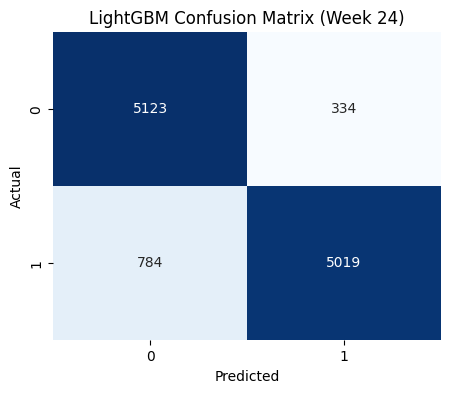

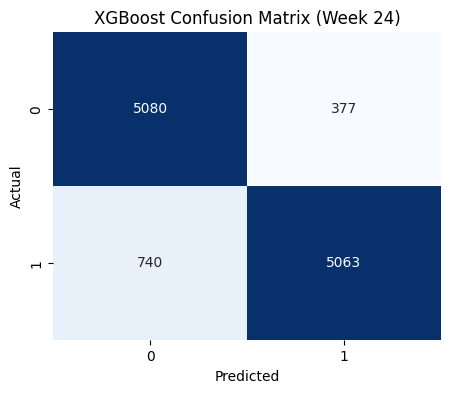

In [4]:
results_lgbm = []
results_xgb = []

for w in CUT_OFF_WEEKS:
    print(f"\n{'='*40}")
    print(f"[*] PROCESSING WEEK {w}")
    print(f"{'='*40}")
    
    # 1. Load Data
    train_file = f'{SEQ_PATH}df_train_week_{w}.csv'
    test_file  = f'{SEQ_PATH}df_test_week_{w}.csv'
    
    if not os.path.exists(train_file):
        print(f"File {train_file} không tồn tại. Bỏ qua tuần {w}.")
        continue
        
    df_train = pd.read_csv(train_file)
    df_test  = pd.read_csv(test_file)
    
    # Drop identifiers
    drop_cols = ['id_student', 'code_module', 'code_presentation', 'target']
    X_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
    y_train = df_train['target']
    X_test  = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])
    y_test  = df_test['target']
    
    # 2. LightGBM
    print("Tuning LightGBM...")
    best_params_lgbm = optimize_hyperparams(X_train, y_train, 'lgbm', N_TRIALS)
    best_params_lgbm.update({'random_state': 42, 'n_jobs': -1, 'device': 'gpu', 'verbose': -1})
    model_lgbm = LGBMClassifier(**best_params_lgbm)
    with SuppressStderr():
        model_lgbm.fit(X_train, y_train)
    probs_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
    metrics_lgbm = evaluate_predictions(y_test, probs_lgbm)
    metrics_lgbm['week'] = w
    joblib.dump(model_lgbm, f'{MODEL_PATH}lgbm_model_week_{w}.pkl')
    results_lgbm.append(metrics_lgbm)
    print(f"LightGBM Week {w} - AUC: {metrics_lgbm['auc']:.4f}, F1: {metrics_lgbm['f1']:.4f}")
    
    # 3. XGBoost
    print("Tuning XGBoost...")
    best_params_xgb = optimize_hyperparams(X_train, y_train, 'xgb', N_TRIALS)
    best_params_xgb.update({'random_state': 42, 'n_jobs': -1, 'eval_metric': 'logloss', 'tree_method': 'hist', 'device': 'cuda', 'verbosity': 0})
    model_xgb = XGBClassifier(**best_params_xgb)
    with SuppressStderr():
        model_xgb.fit(X_train, y_train)
    probs_xgb = model_xgb.predict_proba(X_test)[:, 1]
    metrics_xgb = evaluate_predictions(y_test, probs_xgb)
    metrics_xgb['week'] = w
    joblib.dump(model_xgb, f'{MODEL_PATH}xgb_model_week_{w}.pkl')
    results_xgb.append(metrics_xgb)
    print(f"XGBoost Week {w} - AUC: {metrics_xgb['auc']:.4f}, F1: {metrics_xgb['f1']:.4f}")
    
    # Show Confusion Matrix for the last week as an example
    if w == CUT_OFF_WEEKS[-1]:
        plot_confusion_matrix(y_test, (probs_lgbm > 0.5).astype(int), f"LightGBM Confusion Matrix (Week {w})")
        plot_confusion_matrix(y_test, (probs_xgb > 0.5).astype(int), f"XGBoost Confusion Matrix (Week {w})")

df_res_lgbm = pd.DataFrame(results_lgbm)[['week', 'auc', 'accuracy', 'precision', 'recall', 'f1']]
df_res_xgb = pd.DataFrame(results_xgb)[['week', 'auc', 'accuracy', 'precision', 'recall', 'f1']]


## 4. Tổng kết Realtime Performance


=== LIGHTGBM REALTIME PERFORMANCE ===


,week,auc,accuracy,precision,recall,f1
0,4,0.8200,0.7095,0.6711,0.8556,0.7522
1,8,0.8694,0.7834,0.8583,0.6943,0.7676
2,12,0.8855,0.7903,0.7893,0.8091,0.7991
3,16,0.9300,0.8521,0.9287,0.7724,0.8434
4,20,0.9452,0.8750,0.9079,0.8430,0.8743
5,24,0.9624,0.9007,0.9376,0.8649,0.8998



=== XGBOOST REALTIME PERFORMANCE ===


,week,auc,accuracy,precision,recall,f1
0,4,0.8189,0.7131,0.6807,0.8349,0.7499
1,8,0.8719,0.7861,0.8691,0.6888,0.7685
2,12,0.8780,0.7868,0.8018,0.7787,0.7901
3,16,0.9288,0.8521,0.9170,0.7841,0.8453
4,20,0.9465,0.8806,0.9238,0.8373,0.8784
5,24,0.9629,0.9008,0.9307,0.8725,0.9006


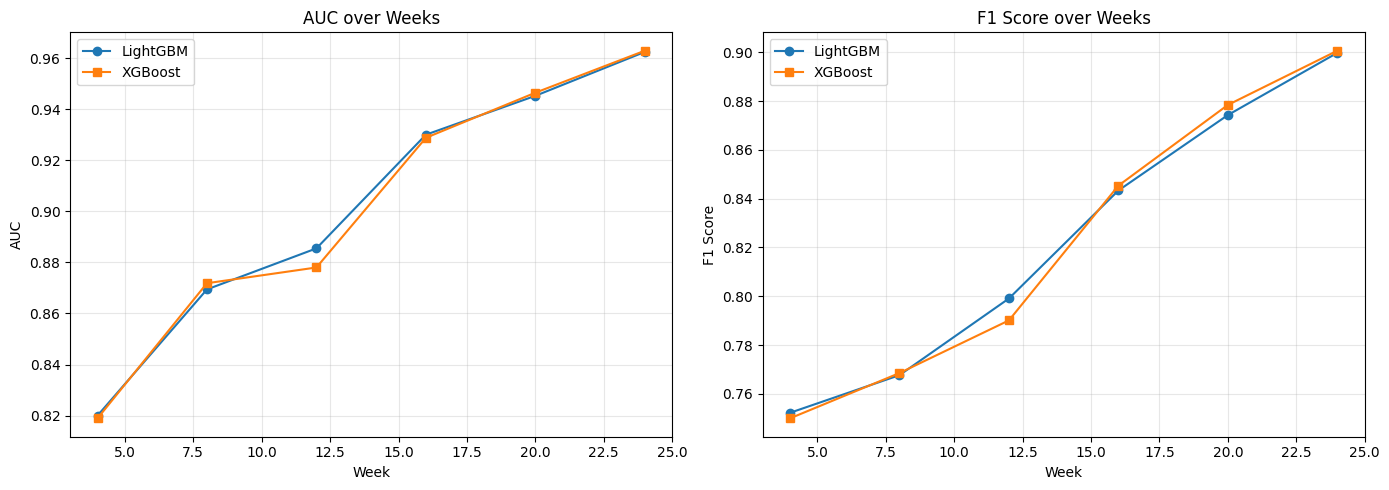

In [5]:
print("\n=== LIGHTGBM REALTIME PERFORMANCE ===")
display(df_res_lgbm.round(4))

print("\n=== XGBOOST REALTIME PERFORMANCE ===")
display(df_res_xgb.round(4))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_res_lgbm['week'], df_res_lgbm['auc'], 'o-', label='LightGBM')
axes[0].plot(df_res_xgb['week'], df_res_xgb['auc'], 's-', label='XGBoost')
axes[0].set_title('AUC over Weeks')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_res_lgbm['week'], df_res_lgbm['f1'], 'o-', label='LightGBM')
axes[1].plot(df_res_xgb['week'], df_res_xgb['f1'], 's-', label='XGBoost')
axes[1].set_title('F1 Score over Weeks')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()